# AI651 PA1, Task 2: Analysis

The comparisons used in the report: baselines, the external-data ablation of the final model, and the design changes between the three leaderboard attempts. Attempt runs are loaded from `../v1`, `../v2` and `../v3`; runs that exist only for analysis are in `results/runs`.

| Config | Description | Notebook |
|---|---|---|
| `v1` | linear covariate head, dropout 0.1, learning rate halved each epoch | `../v1/Task2_v1.ipynb` |
| `v1_reg` | `v1` with dropout 0.25, weight decay and a cosine schedule | analysis only |
| `v2` | non-linear covariate head, regularised (floor applied after prediction) | `../v2/Task2_v2.ipynb` |
| `v3` | `v2` with a floor layer (final) | `../v3/Task2_v3.ipynb` |

In [1]:
import json, os, sys, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

HERE = os.path.abspath("")
ROOT = os.path.dirname(HERE)
sys.path.insert(0, ROOT)
from autoformer.AutoCorrelation import AutoCorrelation, AutoCorrelationLayer
from autoformer.Autoformer_EncDec import (Encoder, Decoder, EncoderLayer, DecoderLayer,
                                          my_Layernorm, series_decomp)

DATA = os.path.join(ROOT, "Data")
RES = os.path.join(HERE, "results")
RUN_DIR = os.path.join(RES, "runs")
FIG = os.path.join(HERE, "figures")
os.makedirs(RUN_DIR, exist_ok=True); os.makedirs(FIG, exist_ok=True)
torch.set_num_threads(max(1, os.cpu_count() // 2))

RUN_EXPERIMENTS = False  # True retrains every run from scratch; False loads the saved models in results/runs

In [2]:
SEQ_LEN, LABEL_LEN, PRED_LEN = 168, 48, 168
N_HIST = 43656
N_EVAL_BLOCKS, N_ES_BLOCKS = 24, 12
EVAL_START = N_HIST - N_EVAL_BLOCKS * PRED_LEN
ES_START = EVAL_START - N_ES_BLOCKS * PRED_LEN
EVAL_ORIGINS = [EVAL_START + k * PRED_LEN for k in range(N_EVAL_BLOCKS)]
PERIODS = (24.0, 8766.0)
SEEDS = [0, 1, 2]
CONT = ["feature_A", "feature_B", "feature_C", "feature_D", "feature_E", "feature_F"]
BIN = ["feature_G", "feature_H", "feature_I", "feature_J"]
LOG_COLS = ["feature_D", "feature_E", "feature_F"]

_BODY = dict(d_model=32, n_heads=4, e_layers=1, d_layers=1, d_ff=64, moving_avg=25, factor=1)
_T_HALVE = dict(batch=64, lr=3e-4, exo_lr=1e-2, max_epochs=10, patience=3, train_stride=2,
                weight_decay=0.0, schedule="halve")
_T_REG = dict(batch=64, lr=3e-4, exo_lr=1e-2, max_epochs=15, patience=4, train_stride=2,
              weight_decay=1e-4, schedule="cosine")
_T_CONV = dict(_T_REG, exo_lr=3e-3)
CONFIGS = {
    "v1":     {"model": dict(_BODY, dropout=0.1), "head": "linear", "floor_layer": False, "train": _T_HALVE},
    "v1_reg": {"model": dict(_BODY, dropout=0.25), "head": "linear", "floor_layer": False, "train": _T_REG},
    "v2":     {"model": dict(_BODY, dropout=0.25), "head": "conv", "floor_layer": False, "train": _T_CONV},
    "v3":     {"model": dict(_BODY, dropout=0.25), "head": "conv", "floor_layer": True, "train": _T_CONV},
}

In [3]:
def load():
    y = pd.read_csv(os.path.join(DATA, "student_train.csv"))["value"].to_numpy(float)
    X = pd.read_csv(os.path.join(DATA, "optional_external_data.csv"))
    assert len(y) == N_HIST and len(X) == N_HIST + PRED_LEN
    t = X["time_idx"].to_numpy(float)
    phase = np.concatenate([np.stack([np.sin(2 * np.pi * t / p), np.cos(2 * np.pi * t / p)], 1)
                            for p in PERIODS], 1).astype(np.float32)
    cov = X[CONT + BIN].copy()
    for c in LOG_COLS:
        cov[c] = np.log1p(cov[c])
    cov = cov.to_numpy(float)
    mu, sd = cov[:ES_START].mean(0), cov[:ES_START].std(0) + 1e-8
    mu[len(CONT):], sd[len(CONT):] = 0.0, 1.0
    cov = ((cov - mu) / sd).astype(np.float32)
    return y, phase, cov, X


class Scaler:
    def __init__(self, y):
        self.m, self.s = float(y[:ES_START].mean()), float(y[:ES_START].std())
    def f(self, v): return (v - self.m) / self.s
    def inv(self, v): return v * self.s + self.m


def make_batch(origins, ys, menc, mdec):
    xe = np.stack([ys[o - SEQ_LEN:o] for o in origins])[..., None]
    me = np.stack([menc[o - SEQ_LEN:o] for o in origins])
    md = np.stack([mdec[o - LABEL_LEN:o + PRED_LEN] for o in origins])
    return torch.tensor(xe), torch.tensor(me), torch.tensor(md)


def target(origins, ys):
    return torch.tensor(np.stack([ys[o:o + PRED_LEN] for o in origins])[..., None])

y, phase, cov, X = load()
sc = Scaler(y)
ys = sc.f(y).astype(np.float32)
FLOOR = float(np.percentile(y[:ES_START], 10))
truth = np.stack([y[o:o + PRED_LEN] for o in EVAL_ORIGINS])

In [4]:
class Embedding(nn.Module):
    def __init__(self, c_in, mark_dim, d_model, dropout):
        super().__init__()
        self.value = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.mark = nn.Linear(mark_dim, d_model, bias=False)
        self.drop = nn.Dropout(dropout)

    def forward(self, x, m):
        return self.drop(self.value(x.permute(0, 2, 1)).transpose(1, 2) + self.mark(m))


class Autoformer(nn.Module):
    def __init__(self, enc_mark, dec_mark, d_model, n_heads, e_layers, d_layers, d_ff, moving_avg,
                 factor, dropout, head="linear", floor_std=None):
        super().__init__()
        self.head = head
        if floor_std is not None:
            self.register_buffer("floor_std", torch.tensor(float(floor_std)))
        self.floor_layer = floor_std is not None
        if head == "conv":
            self.exo = nn.Sequential(nn.Conv1d(dec_mark, 16, 5, padding=2), nn.GELU(), nn.Conv1d(16, 1, 1))
        else:
            self.exo = nn.Linear(dec_mark, 1)
        self.decomp = series_decomp(moving_avg)
        self.enc_emb = Embedding(1, enc_mark, d_model, dropout)
        self.dec_emb = Embedding(1, dec_mark, d_model, dropout)
        AC = lambda mask: AutoCorrelationLayer(
            AutoCorrelation(mask, factor, attention_dropout=dropout), d_model, n_heads)
        self.encoder = Encoder([EncoderLayer(AC(False), d_model, d_ff, moving_avg=moving_avg,
                                             dropout=dropout, activation="gelu")
                                for _ in range(e_layers)], norm_layer=my_Layernorm(d_model))
        self.decoder = Decoder([DecoderLayer(AC(True), AC(False), d_model, 1, d_ff,
                                             moving_avg=moving_avg, dropout=dropout, activation="gelu")
                                for _ in range(d_layers)], norm_layer=my_Layernorm(d_model),
                               projection=nn.Linear(d_model, 1, bias=True))

    def forward(self, x, m_enc, m_dec):
        mean = x.mean(1, keepdim=True).repeat(1, PRED_LEN, 1)
        zeros = torch.zeros(x.shape[0], PRED_LEN, 1)
        seasonal, trend = self.decomp(x)
        trend_init = torch.cat([trend[:, -LABEL_LEN:], mean], 1)
        seas_init = torch.cat([seasonal[:, -LABEL_LEN:], zeros], 1)
        enc, _ = self.encoder(self.enc_emb(x, m_enc))
        s, t = self.decoder(self.dec_emb(seas_init, m_dec), enc, trend=trend_init)
        out = (s + t)[:, -PRED_LEN:]
        if self.head == "conv":
            out = out + self.exo(m_dec.transpose(1, 2)).transpose(1, 2)[:, -PRED_LEN:]
        else:
            out = out + self.exo(m_dec[:, -PRED_LEN:])
        return torch.maximum(out, self.floor_std) if self.floor_layer else out


def build_model(menc, mdec, cfg):
    return Autoformer(menc.shape[1], mdec.shape[1], **cfg["model"], head=cfg["head"],
                      floor_std=sc.f(FLOOR) if cfg["floor_layer"] else None)


def marks_for(variant):
    """(encoder marks, decoder marks): no covariates / covariates up to the origin / also over the horizon."""
    if variant == "none":
        return phase, phase
    if variant == "past":
        return np.concatenate([phase, cov], 1), phase
    both = np.concatenate([phase, cov], 1)
    return both, both

In [5]:
def predict(model, origins, series, menc, mdec, lower=0.0):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(origins), 256):
            out.append(model(*make_batch(origins[i:i + 256], series, menc, mdec)).squeeze(-1).numpy())
    return np.clip(sc.inv(np.concatenate(out)), lower, None)


def train(seed, menc, mdec, cfg, train_end=ES_START, early_stop=True, epochs=None, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    model = build_model(menc, mdec, cfg)
    t_cfg = cfg["train"]
    exo_ids = {id(p) for p in model.exo.parameters()}
    opt = torch.optim.AdamW(
        [{"params": [p for p in model.parameters() if id(p) not in exo_ids], "lr": t_cfg["lr"]},
         {"params": list(model.exo.parameters()), "lr": t_cfg["exo_lr"]}],
        weight_decay=t_cfg["weight_decay"])
    max_ep = epochs or t_cfg["max_epochs"]
    sched = (torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_ep)
             if t_cfg["schedule"] == "cosine" else None)
    lossf = nn.MSELoss()
    tr = np.arange(SEQ_LEN, train_end - PRED_LEN + 1, t_cfg["train_stride"])
    es_orig = np.arange(ES_START, EVAL_START - PRED_LEN + 1, 24)
    best, best_ep, bad, state, hist = np.inf, 0, 0, None, []
    rng = np.random.default_rng(seed)
    for ep in range(1, max_ep + 1):
        model.train(); t0 = time.time(); perm = rng.permutation(tr); tl = []
        for i in range(0, len(perm), t_cfg["batch"]):
            o = perm[i:i + t_cfg["batch"]]
            loss = lossf(model(*make_batch(o, ys, menc, mdec)), target(o, ys))
            opt.zero_grad(); loss.backward(); opt.step(); tl.append(loss.item())
        if sched is not None:
            sched.step()
        else:
            for g in opt.param_groups:
                g["lr"] *= 0.5
        rec = dict(epoch=ep, train_loss=float(np.mean(tl)), sec=round(time.time() - t0, 1))
        if early_stop:
            model.eval()
            with torch.no_grad():
                vl = float(np.mean([lossf(model(*make_batch(es_orig[i:i + 256], ys, menc, mdec)),
                                          target(es_orig[i:i + 256], ys)).item()
                                    for i in range(0, len(es_orig), 256)]))
            rec["es_loss"] = vl
            if vl < best - 1e-4:
                best, best_ep, bad = vl, ep, 0
                state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                bad += 1
        hist.append(rec)
        if verbose:
            print(json.dumps(rec))
        if early_stop and bad >= t_cfg["patience"]:
            break
    if early_stop:
        model.load_state_dict(state)
    return model, dict(history=hist, best_epoch=best_ep if early_stop else max_ep, epochs_run=len(hist))


def metrics(t, p):
    d = np.abs(t - p)
    return dict(MAE=float(d.mean()), RMSE=float(np.sqrt(np.mean(d ** 2))),
                sMAPE=float(np.mean(200 * d / (np.abs(t) + np.abs(p) + 1e-12))))


def week_scores(preds):
    """Per-week metrics averaged over the 24 evaluation weeks, plus RMSE on weeks 12-23."""
    w = [metrics(truth[k], preds[k]) for k in range(N_EVAL_BLOCKS)]
    out = {m: float(np.mean([r[m] for r in w])) for m in ("MAE", "RMSE", "sMAPE")}
    out["RMSE weeks 12-23"] = float(np.mean([r["RMSE"] for r in w[12:]]))
    return out

## 1. Baselines
Naive forecasts on the 24 evaluation weeks.

In [6]:
train_mean = y[:ES_START].mean()
baselines = {
    "Persistence (last value)": [np.full(PRED_LEN, y[o - 1]) for o in EVAL_ORIGINS],
    "Seasonal naive (24)": [np.tile(y[o - 24:o], 7) for o in EVAL_ORIGINS],
    "Mean of last 168": [np.full(PRED_LEN, y[o - 168:o].mean()) for o in EVAL_ORIGINS],
    "Training mean": [np.full(PRED_LEN, train_mean) for o in EVAL_ORIGINS],
}
base = pd.DataFrame({k: week_scores(np.array(v)) for k, v in baselines.items()}).T
base.round(1)

,MAE,RMSE,sMAPE,RMSE weeks 12-23
Persistence (last value),96.7,117.4,89.1,174.0
Seasonal naive (24),85.5,108.2,95.3,153.2
Mean of last 168,68.5,83.2,80.0,111.6
Training mean,69.0,82.9,81.0,109.1


## 2. External-data ablation (final model, 3 seeds)
`none`: no covariates. `past`: covariates in the encoder only (known up to the forecast origin). `pastfuture`: covariates also in the decoder over the forecast horizon (the final model).

In [7]:
def load_or_run(cfg, variant, seed, path):
    menc, mdec = marks_for(variant)
    if RUN_EXPERIMENTS:
        model, info = train(seed, menc, mdec, CONFIGS[cfg], verbose=False)
        torch.save(model.state_dict(), path + ".pt")
        json.dump(dict(info, preds=predict(model, EVAL_ORIGINS, ys, menc, mdec).round(2).tolist()),
                  open(path + ".json", "w"))
    return np.array(json.load(open(path + ".json"))["preds"])

attempt_dir = {"v1": "../v1", "v2": "../v2", "v3": "../v3"}
abl = {}
for v in ["none", "past", "pastfuture"]:
    abl[v] = np.array([np.array(json.load(open(os.path.join(attempt_dir["v3"], "results/runs", f"s{s}.json")))["preds"])
                       if v == "pastfuture" else load_or_run("v3", v, s, os.path.join(RUN_DIR, f"v3_{v}_s{s}"))
                       for s in SEEDS])

def seed_table(P):
    r = pd.DataFrame([week_scores(P[s]) for s in SEEDS])
    return {m: f"{r[m].mean():.1f} ± {r[m].std():.1f}" for m in ["MAE", "RMSE", "sMAPE"]}

ablation = pd.DataFrame({v: seed_table(abl[v]) for v in abl}).T
ablation.to_latex(os.path.join(RES, "table_ablation.tex"))
ablation

,MAE,RMSE,sMAPE
none,68.2 ± 2.2,82.5 ± 1.7,78.9 ± 0.9
past,68.9 ± 2.4,82.8 ± 1.4,79.4 ± 1.1
pastfuture,42.0 ± 2.4,56.8 ± 3.0,52.0 ± 0.3


past       vs none: ΔRMSE =   0.36 ± 1.18 (95% CI over weeks), better on 10/24 weeks
pastfuture vs none: ΔRMSE = -25.69 ± 11.29 (95% CI over weeks), better on 18/24 weeks
pastfuture vs past: ΔRMSE = -26.05 ± 11.52 (95% CI over weeks), better on 19/24 weeks


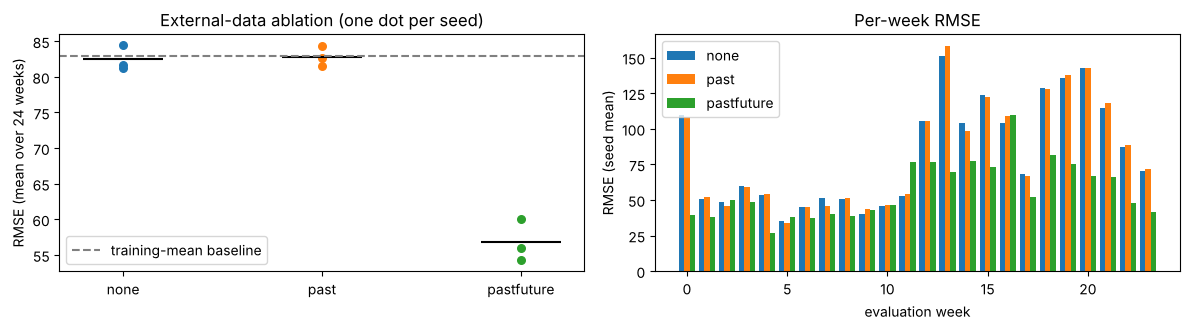

In [8]:
def week_rmse(P):
    return np.sqrt(((np.array(P) - truth) ** 2).mean(-1))

def paired(a, b, label):
    d = week_rmse(a).mean(0) - week_rmse(b).mean(0)
    print(f"{label}: ΔRMSE = {d.mean():6.2f} ± {1.96 * d.std(ddof=1) / np.sqrt(len(d)):.2f} "
          f"(95% CI over weeks), better on {int((d < 0).sum())}/24 weeks")

paired(abl["past"], abl["none"], "past       vs none")
paired(abl["pastfuture"], abl["none"], "pastfuture vs none")
paired(abl["pastfuture"], abl["past"], "pastfuture vs past")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.4))
for i, v in enumerate(abl):
    vals = week_rmse(abl[v]).mean(1)
    ax[0].scatter([i] * 3, vals, s=30); ax[0].hlines(vals.mean(), i - .2, i + .2, color="k")
ax[0].axhline(base.loc["Training mean", "RMSE"], ls="--", c="gray", label="training-mean baseline")
ax[0].set_xticks(range(3), list(abl)); ax[0].set_ylabel("RMSE (mean over 24 weeks)"); ax[0].legend()
ax[0].set_title("External-data ablation (one dot per seed)")
for i, v in enumerate(abl):
    ax[1].bar(np.arange(24) + (i - 1) * 0.27, week_rmse(abl[v]).mean(0), 0.27, label=v)
ax[1].set_xlabel("evaluation week"); ax[1].set_ylabel("RMSE (seed mean)"); ax[1].legend(); ax[1].set_title("Per-week RMSE")
plt.tight_layout(); plt.savefig(f"{FIG}/ablation.pdf"); plt.show()

## 3. Design changes between attempts (`pastfuture`, 3 seeds each)
* Regularisation: `v1` vs `v1_reg`.
* Covariate head: `v1_reg` vs `v2` (same training settings).
* Floor: `v2` clipped at 0, `v2` floored after prediction, and the floor layer trained in (`v3`).
* Refit on recent data: `v1` retrained with the 12 early-stop weeks included, for the same epoch count.

In [9]:
preds = {c: np.array([json.load(open(os.path.join(attempt_dir[c], "results/runs", f"s{s}.json")))["preds"] for s in SEEDS])
         for c in ["v1", "v2", "v3"]}
preds["v1_reg"] = np.array([load_or_run("v1_reg", "pastfuture", s, os.path.join(RUN_DIR, f"v1reg_s{s}")) for s in SEEDS])
if RUN_EXPERIMENTS:
    for s in SEEDS:
        info = json.load(open(os.path.join(attempt_dir["v1"], "results/runs", f"s{s}.json")))
        model, _ = train(s, *marks_for("pastfuture"), CONFIGS["v1"], train_end=EVAL_START, early_stop=False,
                         epochs=info["best_epoch"], verbose=False)
        json.dump({"preds": predict(model, EVAL_ORIGINS, ys, *marks_for("pastfuture")).round(2).tolist()},
                  open(os.path.join(RUN_DIR, f"v1recent_s{s}.json"), "w"))
recent = np.array([json.load(open(os.path.join(RUN_DIR, f"v1recent_s{s}.json")))["preds"] for s in SEEDS])

def summary(P):
    r = week_rmse(P); e = week_rmse(P.mean(0)[None])[0]
    return {"RMSE all 24": f"{r.mean(1).mean():.2f} ± {r.mean(1).std():.2f}",
            "RMSE weeks 12-23": f"{r[:, 12:].mean(1).mean():.2f} ± {r[:, 12:].mean(1).std():.2f}",
            "seed-averaged, all": round(e.mean(), 2), "seed-averaged, 12-23": round(e[12:].mean(), 2),
            "MAE": round(float(np.abs(P - truth).mean()), 2)}

rows = {"v1: linear head (attempt 1 config)": summary(preds["v1"]),
        "v1_reg: linear head, regularised": summary(preds["v1_reg"]),
        "v2: non-linear head, clipped at 0": summary(preds["v2"]),
        "v2: non-linear head, floored after prediction (attempt 2)": summary(np.maximum(preds["v2"], FLOOR)),
        "v3: non-linear head, floor layer (attempt 3)": summary(preds["v3"]),
        "v1 + 12 recent weeks in training": summary(recent)}
design = pd.DataFrame(rows).T
design.to_latex(os.path.join(RES, "table_design.tex"))
design

,RMSE all 24,RMSE weeks 12-23,"seed-averaged, all","seed-averaged, 12-23",MAE
v1: linear head (attempt 1 config),60.50 ± 2.48,75.87 ± 2.43,58.92,74.53,47.58
"v1_reg: linear head, regularised",61.17 ± 2.11,76.20 ± 2.46,59.89,75.31,48.1
"v2: non-linear head, clipped at 0",58.12 ± 2.37,72.72 ± 2.40,56.13,71.47,46.35
"v2: non-linear head, floored after prediction (attempt 2)",57.85 ± 2.42,72.58 ± 2.43,55.96,71.4,45.65
"v3: non-linear head, floor layer (attempt 3)",56.77 ± 2.46,69.89 ± 2.37,54.26,68.34,41.98
v1 + 12 recent weeks in training,59.97 ± 2.39,75.16 ± 2.37,58.14,73.72,46.9


regularised vs not        : ΔRMSE =   0.67 ± 1.36 (95% CI over weeks), better on 6/24 weeks
non-linear vs linear head : ΔRMSE =  -3.05 ± 4.41 (95% CI over weeks), better on 17/24 weeks
floor layer vs post-hoc   : ΔRMSE =  -1.08 ± 2.63 (95% CI over weeks), better on 11/24 weeks


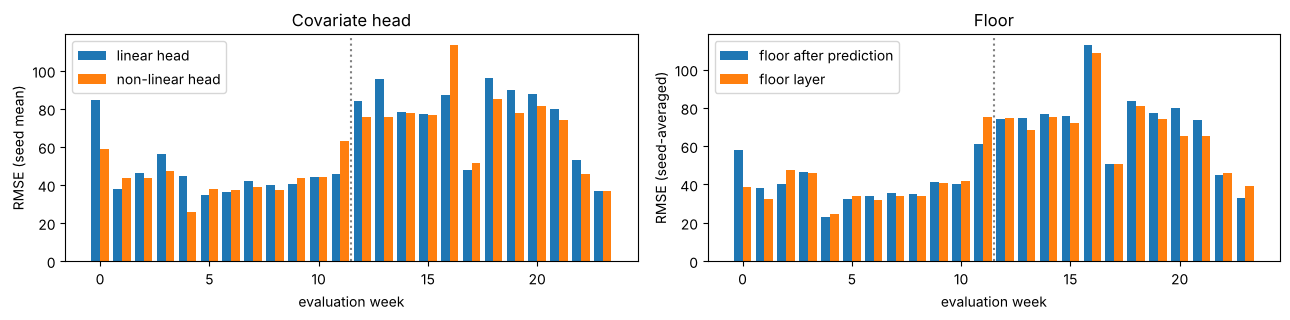

In [10]:
paired(preds["v1_reg"], preds["v1"], "regularised vs not        ")
paired(preds["v2"], preds["v1_reg"], "non-linear vs linear head ")
paired(preds["v3"], np.maximum(preds["v2"], FLOOR), "floor layer vs post-hoc   ")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.3))
ax[0].bar(np.arange(24) - 0.2, week_rmse(preds["v1_reg"]).mean(0), 0.4, label="linear head")
ax[0].bar(np.arange(24) + 0.2, week_rmse(preds["v2"]).mean(0), 0.4, label="non-linear head")
ax[0].axvline(11.5, c="gray", ls=":"); ax[0].set_xlabel("evaluation week"); ax[0].set_ylabel("RMSE (seed mean)")
ax[0].legend(); ax[0].set_title("Covariate head")
ax[1].bar(np.arange(24) - 0.2, week_rmse(np.maximum(preds["v2"], FLOOR).mean(0)[None])[0], 0.4, label="floor after prediction")
ax[1].bar(np.arange(24) + 0.2, week_rmse(preds["v3"].mean(0)[None])[0], 0.4, label="floor layer")
ax[1].axvline(11.5, c="gray", ls=":"); ax[1].set_xlabel("evaluation week"); ax[1].set_ylabel("RMSE (seed-averaged)")
ax[1].legend(); ax[1].set_title("Floor")
plt.tight_layout(); plt.savefig(f"{FIG}/design.pdf"); plt.show()

## 4. Leaderboard attempts
| Attempt | Notebook | P | E | Leaderboard RMSE | Rank |
|---|---|---|---|---|---|
| 1 | `v1` | 22,224 | 4 | 93.82 | ~23 |
| 2 | `v2` | 70,086 | 18 | 71.48 | 8 |
| 3 | `v3` | 70,086 | 18 | **67.22** | **3** |

In [11]:
sub_val = {"attempt 1 (v1, seed 0)": preds["v1"][0],
           "attempt 2 (v2, 3 seeds, floor after)": np.maximum(preds["v2"], FLOOR).mean(0),
           "attempt 3 (v3, 3 seeds, floor layer)": preds["v3"].mean(0)}
lb = {"attempt 1 (v1, seed 0)": 93.82, "attempt 2 (v2, 3 seeds, floor after)": 71.48,
      "attempt 3 (v3, 3 seeds, floor layer)": 67.22}
pd.DataFrame({k: {"validation RMSE, all": week_rmse(p).mean(), "validation RMSE, weeks 12-23": week_rmse(p)[12:].mean(),
                  "leaderboard RMSE": lb[k]} for k, p in sub_val.items()}).T.round(2)

,"validation RMSE, all","validation RMSE, weeks 12-23",leaderboard RMSE
"attempt 1 (v1, seed 0)",63.78,79.30,93.82
"attempt 2 (v2, 3 seeds, floor after)",55.96,71.40,71.48
"attempt 3 (v3, 3 seeds, floor layer)",54.26,68.34,67.22
